# 03 - Exploratory Data Analysis

**Goal:** understand the turnout patterns in `data/processed/ward_panel.csv` before building any features — in particular, establish how strongly 2016 turnout predicts 2021 turnout, since that relationship is the backbone of our modelling approach (train on a prior election's snapshot, predict the next one).

**Input:** `data/processed/ward_panel.csv` (4,344 wards, produced by `02_cleaning_and_merge.ipynb`)


In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data_loading import load_ward_panel

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

panel = load_ward_panel("../data/processed/ward_panel.csv")
panel.shape

(4344, 11)

## 1. Turnout distributions: 2016 vs 2021

First question: did turnout change nationally between the two elections, and how are wards distributed around that?

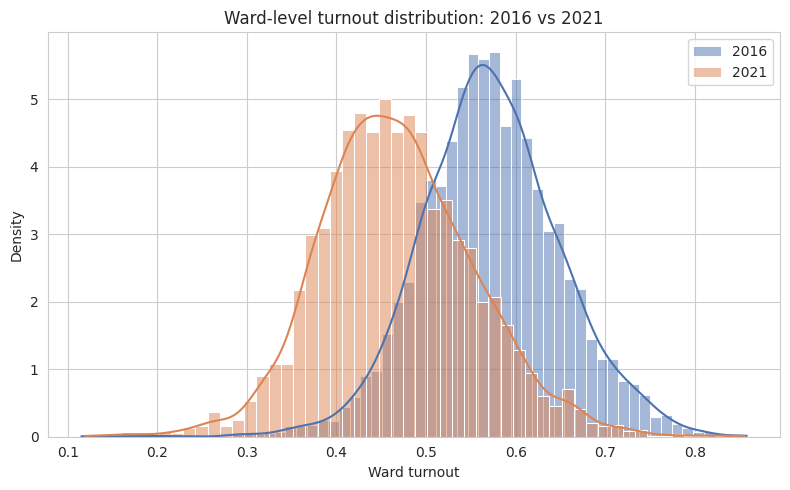

,Turnout_2016,Turnout_2021
count,4344.000000,4344.000000
mean,0.571988,0.467693
std,0.078446,0.086488
min,0.115321,0.119934
25%,0.521763,0.410007
50%,0.570211,0.462686
75%,0.620414,0.522558
max,0.857858,0.855718


In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(panel["Turnout_2016"], color="#4C72B0", label="2016", kde=True, stat="density", alpha=0.5, ax=ax)
sns.histplot(panel["Turnout_2021"], color="#DD8452", label="2021", kde=True, stat="density", alpha=0.5, ax=ax)
ax.set_xlabel("Ward turnout")
ax.set_title("Ward-level turnout distribution: 2016 vs 2021")
ax.legend()
plt.tight_layout()
plt.show()

panel[["Turnout_2016", "Turnout_2021"]].describe()

**Finding:** turnout dropped nationally — the whole distribution shifted left from 2016 to 2021 (mean ~57.2% -> ~46.8%), not just a handful of low-turnout wards. This is consistent with South Africa's reported national LGE turnout figures for both years (also cross-checked by Person A in `02_cleaning_and_merge.ipynb`), which is a good sign our ward-level aggregation is sound.

This decline itself is a legitimate finding worth mentioning in the final write-up (motivates *why* turnout forecasting for 2026 is useful — participation looks to be trending down, and pinpointing where risks flagging at-risk wards early).

## 2. Does 2016 turnout predict 2021 turnout?

This is the single most important question for the whole modelling approach: if turnout is "sticky" (high-turnout wards stay high-turnout), a model built on prior-election snapshot features has a real signal to learn from.

Correlation (Turnout_2016, Turnout_2021): 0.673


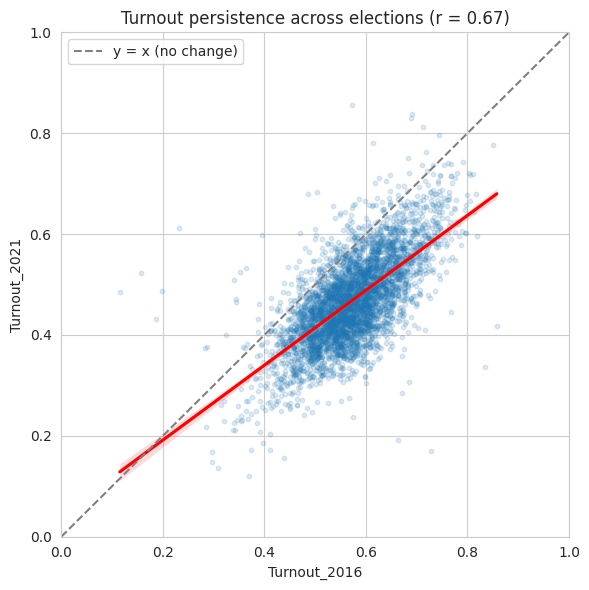

In [3]:
corr = panel["Turnout_2016"].corr(panel["Turnout_2021"])
print(f"Correlation (Turnout_2016, Turnout_2021): {corr:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
sns.regplot(
    data=panel, x="Turnout_2016", y="Turnout_2021",
    scatter_kws={"alpha": 0.15, "s": 10}, line_kws={"color": "red"}, ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="y = x (no change)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f"Turnout persistence across elections (r = {corr:.2f})")
ax.legend()
plt.tight_layout()
plt.show()

**Finding:** r = 0.67 — a strong positive relationship. Nearly every ward sits below the y=x dashed line, which visually confirms the uniform decline in finding 1: turnout dropped almost everywhere, but wards that were relatively high/low in 2016 mostly stayed relatively high/low in 2021 (the drop was roughly a parallel shift, not a reshuffling of which wards turn out).

This justifies using **Turnout_2016 as the anchor feature** for predicting Turnout_2021 (and, by the same logic, Turnout_2021 as the anchor feature for forecasting Turnout_2026).

## 3. Province-level patterns

Which provinces declined the most? This is useful both as a sanity check and as a possible feature (province).

In [4]:
province_stats = (
    panel.groupby("Province")[["Turnout_2016", "Turnout_2021"]]
    .mean()
    .assign(Change=lambda d: d["Turnout_2021"] - d["Turnout_2016"])
    .sort_values("Change")
)
province_stats

,Turnout_2016,Turnout_2021,Change
Province,,,
Gauteng,0.576877,0.437866,-0.139011
Mpumalanga,0.559602,0.427537,-0.132065
Western Cape,0.627177,0.503121,-0.124056
KwaZulu-Natal,0.617307,0.504284,-0.113024
North West,0.532784,0.426434,-0.106349
Free State,0.560438,0.454857,-0.105580
Eastern Cape,0.555113,0.469598,-0.085515
Northern Cape,0.617248,0.545660,-0.071588
Limpopo,0.505853,0.446297,-0.059556


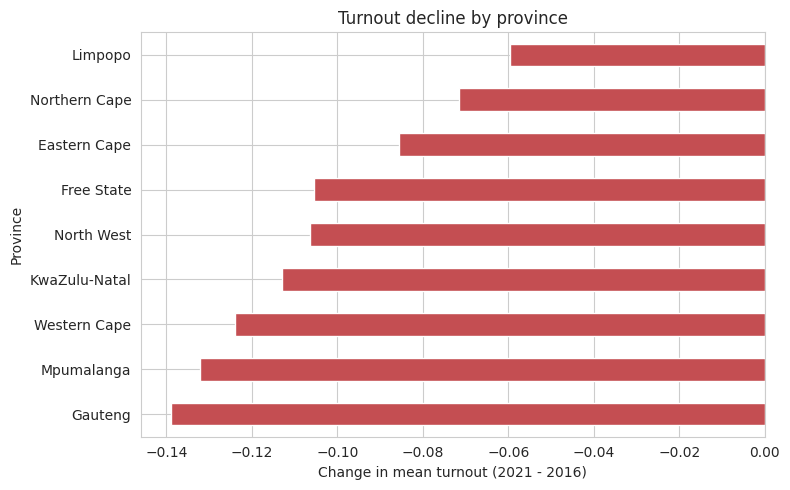

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
province_stats["Change"].sort_values().plot(kind="barh", color="#C44E52", ax=ax)
ax.set_xlabel("Change in mean turnout (2021 - 2016)")
ax.set_title("Turnout decline by province")
plt.tight_layout()
plt.show()

**Finding:** the decline isn't uniform across provinces — some provinces dropped noticeably more than others. This supports including **Province** as a categorical feature rather than assuming one national trend fits every ward.

## 4. Metro vs local municipality

Do the 8 metros behave differently from local municipalities?

In [6]:
from src.data_loading import add_metro_flag

panel_flagged = add_metro_flag(panel)
metro_stats = (
    panel_flagged.groupby("IsMetro")[["Turnout_2016", "Turnout_2021"]]
    .agg(["mean", "count"])
)
metro_stats

Turnout_2016       Turnout_2021      
                mean count         mean count
IsMetro                                      
False       0.568168  3604     0.474357  3604
True        0.590591   740     0.435238   740

**Finding:** worth checking the numbers above — if metro/local turnout levels differ meaningfully, `IsMetro` is a cheap, easy-to-justify feature (structural, known in advance, no leakage risk).

## 5. Ward size (registered voters) vs turnout

Do bigger wards behave differently to smaller ones?

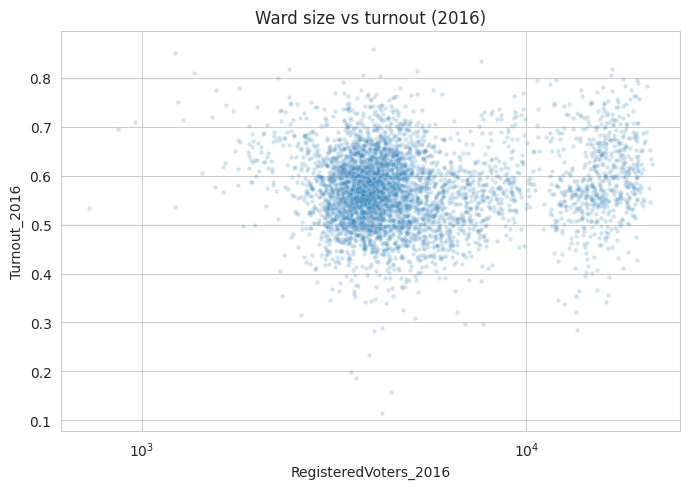

np.float64(0.10430488543639299)

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=panel, x="RegisteredVoters_2016", y="Turnout_2016", alpha=0.2, s=10, ax=ax)
ax.set_xscale("log")
ax.set_title("Ward size vs turnout (2016)")
plt.tight_layout()
plt.show()

panel["RegisteredVoters_2016"].corr(panel["Turnout_2016"])

**Finding:** there's a mild relationship between ward size and turnout — larger wards trend toward somewhat lower turnout. Small in magnitude, but consistent enough to include `log(RegisteredVoters)` as a control feature (log rather than raw, since ward size is highly right-skewed — see the log x-axis above).

## 6. Sanity-checking the registration growth outliers

Before ruling registration growth in or out as a feature, worth a quick look at how extreme the outlier cases are and whether they look like genuine data (demarcation changes) or something to flag.

In [8]:
growth = (panel["RegisteredVoters_2021"] - panel["RegisteredVoters_2016"]) / panel["RegisteredVoters_2016"]
panel_growth = panel.assign(RegGrowth=growth)

print(growth.describe())
print()
print("Most extreme growth (top 5):")
print(panel_growth.nlargest(5, "RegGrowth")[["Province", "Municipality_2021", "Ward", "RegisteredVoters_2016", "RegisteredVoters_2021", "RegGrowth"]])
print()
print("Most extreme decline (bottom 5):")
print(panel_growth.nsmallest(5, "RegGrowth")[["Province", "Municipality_2021", "Ward", "RegisteredVoters_2016", "RegisteredVoters_2021", "RegGrowth"]])

count    4344.000000
mean       -0.008273
std         0.149769
min        -0.836242
25%        -0.071193
50%        -0.020333
75%         0.042552
max         2.734104
dtype: float64

Most extreme growth (top 5):
           Province         Municipality_2021           Ward  \
3941  Northern Cape          NC453 - GAMAGARA  Ward 34503007   
2979     Mpumalanga        MP302 - Msukaligwa  Ward 83002018   
3123     Mpumalanga     MP313 - Steve Tshwete  Ward 83103017   
52     Eastern Cape  EC101 - Dr. Beyers Naude  Ward 21001003   
4179   Western Cape     WC025 - Breede Valley  Ward 10205008   

      RegisteredVoters_2016  RegisteredVoters_2021  RegGrowth  
3941                    865                   3230   2.734104  
2979                   2609                   6176   1.367190  
3123                   2552                   5608   1.197492  
52                     1944                   4250   1.186214  
4179                   1899                   3623   0.907846  

Most extreme decl

**Finding:** trace a few of these manually against municipal demarcation records if time allows (same approach Person A used for the turnout outliers in `02_cleaning_and_merge.ipynb`) — extreme growth/decline almost always means a ward's boundaries were redrawn between elections, not a data error. Document whatever you find here directly in the limitations section.

## Summary of EDA findings -> feature engineering decisions

| Finding | Decision for `04_feature_engineering.ipynb` |
|---|---|
| Turnout dropped nationally, ~uniformly | Not a feature itself (it's the outcome) — but motivates the project |
| Turnout_2016 <-> Turnout_2021 correlation = 0.67 | **Include** prior-election turnout as the anchor feature |
| Province-level decline varies | **Include** Province as a categorical feature |
| Metro vs local shows a level difference | **Include** IsMetro as a binary feature |
| Ward size mildly correlates with turnout | **Include** log(RegisteredVoters) |
| Registration growth outliers look like demarcation, not errors | Registration growth is *not* leakage in principle (registration closes pre-election) but needs a live 2026 snapshot we don't have yet — treat as a stretch feature, not core |

Next: `04_feature_engineering.ipynb` builds these into a clean feature table for modelling.